In [1]:
import pandas as pd
import numpy as np


In [2]:
df=pd.read_csv(r"C:\Users\shaik zabiulla\Downloads\powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [3]:
x=df.drop("PE",axis=1)
y=df["PE"]
x.head()
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [4]:
from sklearn .model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [5]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_trained_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)


In [6]:
x_trained_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]])

In [7]:
import torch
import torch .nn as nn
x_train_tensor=torch.tensor(x_trained_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
x_test_tensor=torch.tensor(x_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)


In [8]:
from torch.utils.data import TensorDataset,DataLoader
training_dataset=TensorDataset(x_train_tensor,y_train_tensor)
test_dataset=TensorDataset(x_test_tensor,y_test_tensor)


In [9]:
train_loader=DataLoader(training_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

In [10]:
#defining model
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        self.model=nn.Sequential(
            #1 hidden layer
            nn.Linear(x_train.shape[1],6),
            nn.ReLU(),
            #2 hidden layer
            nn.Linear(6,6),
            nn.ReLU(),
            #output layer
            nn.Linear(6,1),
            
    
        )
    def forward(self,x):
        return self.model(x)

In [11]:
import torch.optim as optim
model=ANN()
# LOSS OPTIMIZER
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

In [12]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = criterion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update
        
        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch 1/100 ==> train loss = 206029.74329427083 & val loss = 203975.6875
epoch 2/100 ==> train loss = 196821.503125 & val loss = 184616.6875
epoch 3/100 ==> train loss = 161044.1441080729 & val loss = 131933.5
epoch 4/100 ==> train loss = 99780.25441080729 & val loss = 70146.796875
epoch 5/100 ==> train loss = 50131.99652506511 & val loss = 35946.99609375
epoch 6/100 ==> train loss = 29162.381429036457 & val loss = 24382.662109375
epoch 7/100 ==> train loss = 21621.260026041666 & val loss = 19175.07421875
epoch 8/100 ==> train loss = 17408.521350097657 & val loss = 15371.7001953125
epoch 9/100 ==> train loss = 13714.075209554036 & val loss = 11868.607421875
epoch 10/100 ==> train loss = 10324.15965576172 & val loss = 8619.6494140625
epoch 11/100 ==> train loss = 7239.368147786458 & val loss = 5795.857421875
epoch 12/100 ==> train loss = 4730.495017496744 & val loss = 3678.312744140625
epoch 13/100 ==> train loss = 2973.9756846110026 & val loss = 2318.23681640625
epoch 14/100 ==> train 

Text(0, 0.5, 'losses')

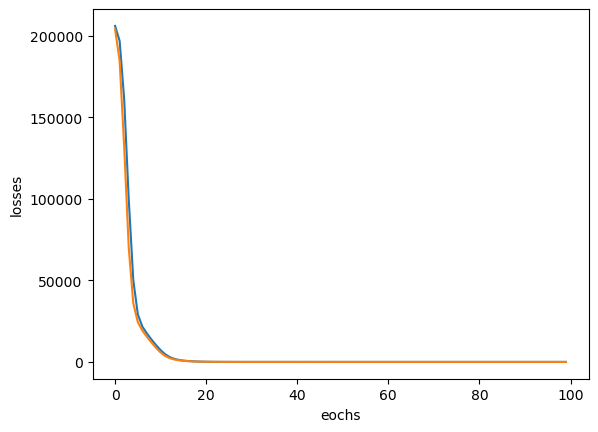

In [13]:
import matplotlib.pyplot as plt
loss_df=pd.DataFrame({
    "train_loss":train_losses,

    "validation_loss":val_losses
})
plt.plot(loss_df["train_loss"],label="train_loss")
plt.plot(loss_df["validation_loss"],label="validation_loss")
plt.xlabel("eochs")
plt.ylabel("losses")

In [14]:
model.load_state_dict (torch.load("best_model.pt"))

<All keys matched successfully>

In [15]:
#evaluation 
model.eval()
with torch.no_grad():
    train_preds = model(x_train_tensor)
    test_preds = model(x_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())


Training MSE: 21.13819694519043
Testing MSE: 19.47356605529785


In [16]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.9319449161388499


In [17]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.415619,433.27
1,437.179901,438.16
2,460.964020,458.42
3,475.893219,480.82
4,435.378571,441.41
...,...,...
1909,451.324280,456.70
1910,431.839813,438.04
1911,467.534790,467.80
1912,431.322327,437.14


In [18]:
#linear regression
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [20]:
r2=r2_score(y_test,y_pred)
r2

0.9314747936670362